# Домашнее задание 6. Визуализация данных в Python

**Домашнее задание состоит из восьми задач, которые вам нужно решить.**

* За каждую выполненную без ошибок задачу вы полные баллы.
* Если задача решена частично или с некритичной ошибкой, вы можете получить до половины баллов.
* За нерешенную или решенную неверно задачу баллы не ставятся.

**Инструкция:** выполните задания в этом же ноутбуке (места под решения каждой задачи обозначаются как **#НАЧАЛО ВАШЕГО РЕШЕНИЯ** и **#КОНЕЦ ВАШЕГО РЕШЕНИЯ**).

**Перед выполнением задания:**
* Перезапустите ядро (restart the kernel): в меню выбрать Ядро (Kernel) → Перезапустить (Restart).
* Выполните все ячейки (run all cells): в меню выбрать Ячейка (Cell) → Запустить все (Run All).


## Введение

Банк обращается к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов, но для этого необходимо выяснить основные причины их оттока. Иными словами, нужно установить, чем ушедшие клиенты отличаются от лояльных и как связаны различные признаки, описывающие клиентов.

После разведывательного анализа, с целью выявления наиболее важных факторов оттока, банк сможет построить модель машинного обучения для прогнозирования ухода клиента.


**Описание столбцов датасета**:

| Название столбца     | Описание                                                                 |
|----------------------|--------------------------------------------------------------------------|
| CustomerId           | Идентификатор клиента                                                    |
| Surname              | Фамилия клиента                                                          |
| CreditScore          | Кредитный рейтинг клиента (чем выше, тем надёжнее клиент)                |
| Geography            | Страна клиента (банк международный)                                      |
| Gender               | Пол клиента                                                              |
| Age                  | Возраст клиента                                                          |
| Tenure               | Сколько лет клиент пользуется услугами банка                             |
| Balance              | Баланс на счетах клиента в банке                                         |
| NumOfProducts        | Количество услуг банка, которые приобрёл клиент                          |
| HasCrCard            | Есть ли у клиента кредитная карта (1 — да, 0 — нет)                      |
| IsActiveMember       | Статус активного клиента (1 — да, 0 — нет)                               |
| EstimatedSalary      | Предполагаемая заработная плата клиента                                  |
| Exited               | Статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)              |

**Советы по выполнению**:
* Для построения графиков используйте библиотеки [Matplotlib](https://matplotlib.org/), [Seaborn](https://seaborn.pydata.org/) или [Plotly](https://plotly.com/python/).
* К каждому заданию обязательно постройте хотя бы один график и запишите выводы, которые можно сделать на его основе.
* Перед началом обязательно определите, какие признаки являются числовыми, а какие категориальными, чтобы правильно выбрать тип визуализации.


In [1]:
# Ячейка для выгрузки необходимых библиотек
# Дополняйте ее по своим возможностям и потребностям
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

In [2]:
# Чтение данных
df = pd.read_csv('bank_clients.csv')
print(df.shape)
df.describe()

(2509, 14)


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,2509.000000,2.509000e+03,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.00000,2509.000000,2509.000000,2509.000000
mean,5000.278996,1.569056e+07,651.453567,39.771622,5.009964,119730.116134,1.519729,0.71383,0.497409,101113.435102,0.324432
std,2918.980192,7.322843e+04,98.168937,10.519143,2.935154,27022.006157,0.619420,0.45206,0.500093,58263.011501,0.468256
min,8.000000,1.556578e+07,350.000000,18.000000,0.000000,27288.430000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2461.000000,1.562740e+07,584.000000,32.000000,2.000000,102800.720000,1.000000,0.00000,0.000000,51016.020000,0.000000
50%,4997.000000,1.568989e+07,651.000000,38.000000,5.000000,119703.100000,1.000000,1.00000,0.000000,102397.220000,0.000000
75%,7583.000000,1.575573e+07,722.000000,45.000000,8.000000,137560.380000,2.000000,1.00000,1.000000,151083.800000,1.000000
max,9999.000000,1.581566e+07,850.000000,84.000000,10.000000,214346.960000,4.000000,1.00000,1.000000,199970.740000,1.000000


## Задание 1 (12 баллов)
Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

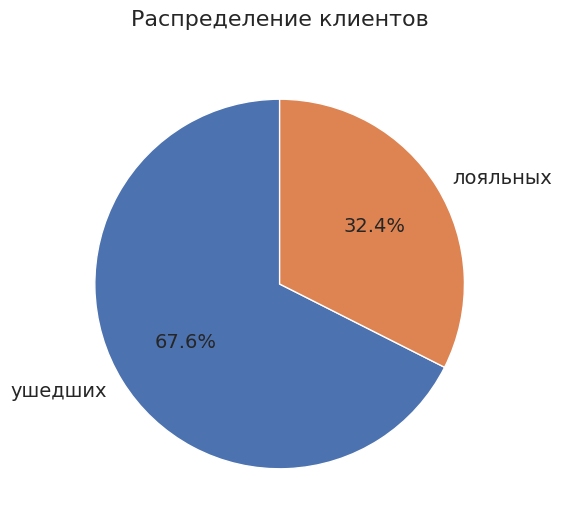

In [3]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
Exited_count = df.groupby('Exited').agg('count').CustomerId

plt.figure(figsize=(6, 6))
plt.pie(
    Exited_count,
    labels=['ушедших', 'лояльных'],
    #colors=['#ff9899', '#66b5ff'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 14}
)
plt.title('Распределение клиентов', fontsize=16, pad=20)
plt.show()
#КОНЕЦ ВАШЕГО РЕШЕНИЯ

Вывод: По графику видно, что больше половины клиентов уходит из банка, лояльных остается только 32.4 %


## Задание 2 (12 баллов)
Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

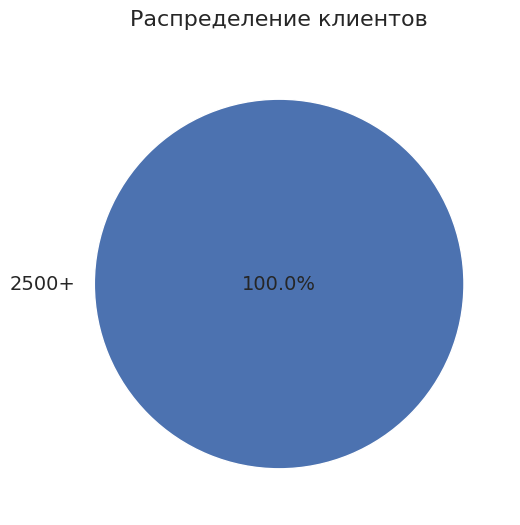

In [4]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
balance_category = df['Balance'] > 2500
counts = balance_category.value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=['2500+'],
    autopct='%1.1f%%',
    pctdistance=0.0001,
    textprops={'fontsize': 14}
)
plt.title('Распределение клиентов', fontsize=16, pad=20)
plt.show()

#КОНЕЦ ВАШЕГО РЕШЕНИЯ

Вывод: у всех пользователей балан выше 2500, минимальный баланс 27288.430000


## Задание 3 (12 баллов)

Постройте тепловую карту по корреляционной матрице (Пирсона), сделайте выводы о линейной взаимосвязи между признаками.

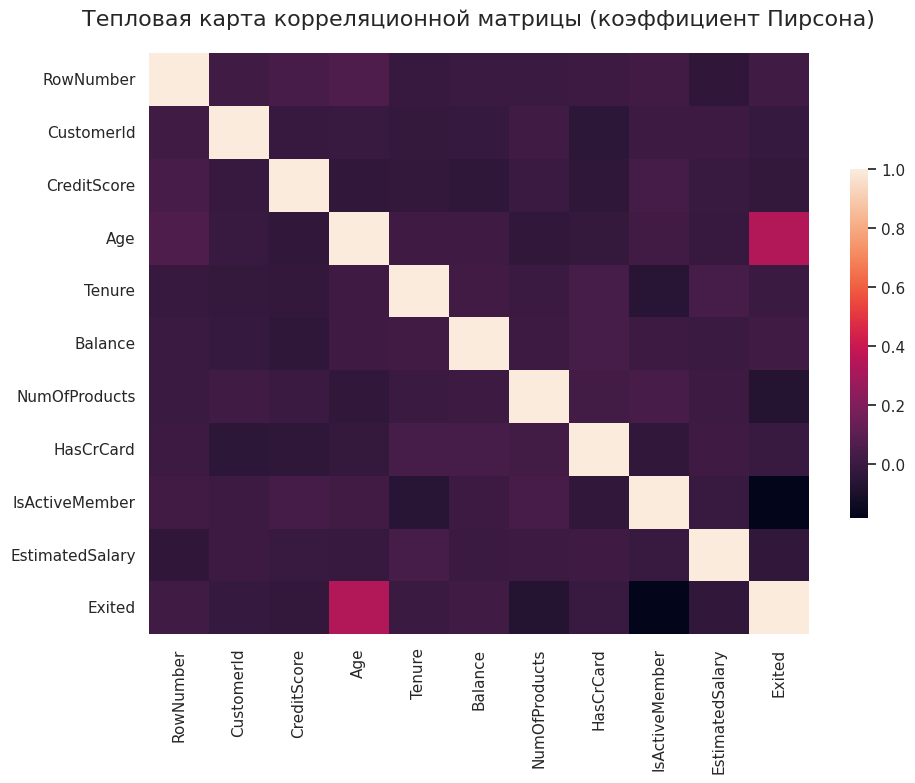

In [5]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ

# Вычисляем корреляционную матрицу (коэффициент Пирсона)
num_columns = ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure','Balance', \
                'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
num_matrix = df[num_columns]
corr_matrix = num_matrix.corr()

# Настройка размера фигуры
plt.figure(figsize=(10, 8))

# Строим тепловую карту
sns.heatmap(
    corr_matrix,
    #cmap='RdBu_r',
    #cmap='bwr',
    #cmap = 'coolwarm',
    #vmin=-1, vmax=1,   # Диапазон корреляций: от –1 до +1
    cbar_kws={'shrink': 0.6}  # Размер цветовой шкалы
)

# Заголовок и оформление
plt.title('Тепловая карта корреляционной матрицы (коэффициент Пирсона)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

#КОНЕЦ ВАШЕГО РЕШЕНИЯ

Вывод: самая заметная корреляция - зависимость возраста от оттока (Age-Exited). Гипотезами могут быть:
1. Зависимость оттока от активности (IsActiveMember-Exited)
2. Зависимость оттока от количества продуктов (NumOfProducts-Exited)
3. Зависимость активность от количества лет в банке (IsActiveMember-Tenure)

## Задание 4 (12 баллов)
Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

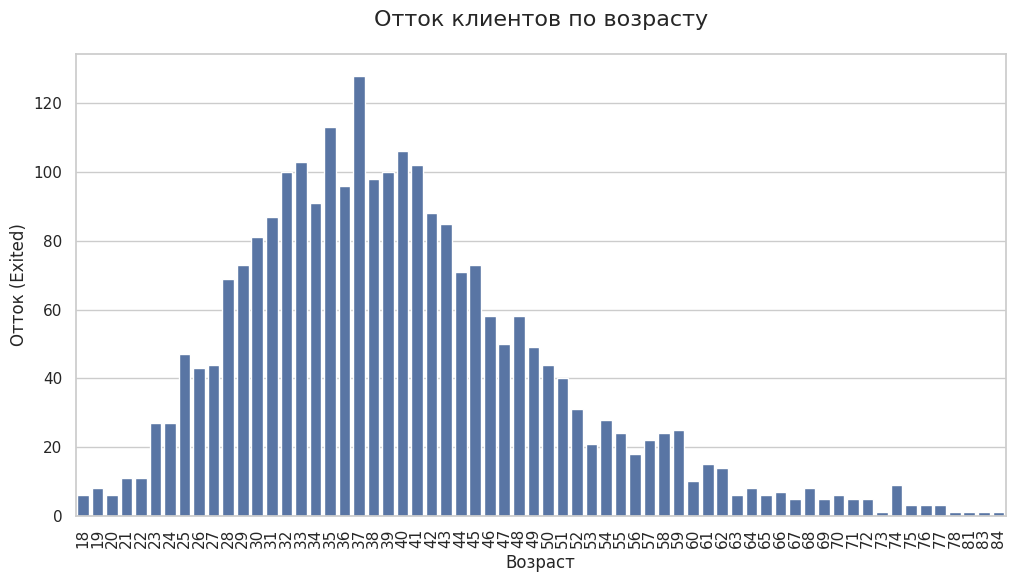

In [6]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
age_churn = df.groupby('Age').agg({'Exited':'count'})

plt.figure(figsize=(12, 6))
sns.barplot(data=age_churn, x='Age', y='Exited')
plt.title('Отток клиентов по возрасту', fontsize=16, pad=20)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Отток (Exited)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=1)
plt.show()

#КОНЕЦ ВАШЕГО РЕШЕНИЯ


Вывод: Самый большой отток 37 летних клиентов. Стоит обратить внимание на группу людей с возрастом от 28 до 46, так как отток самый большой


## Задание 5 (13 баллов)
Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Есть ли взаимосвязь между признаками?

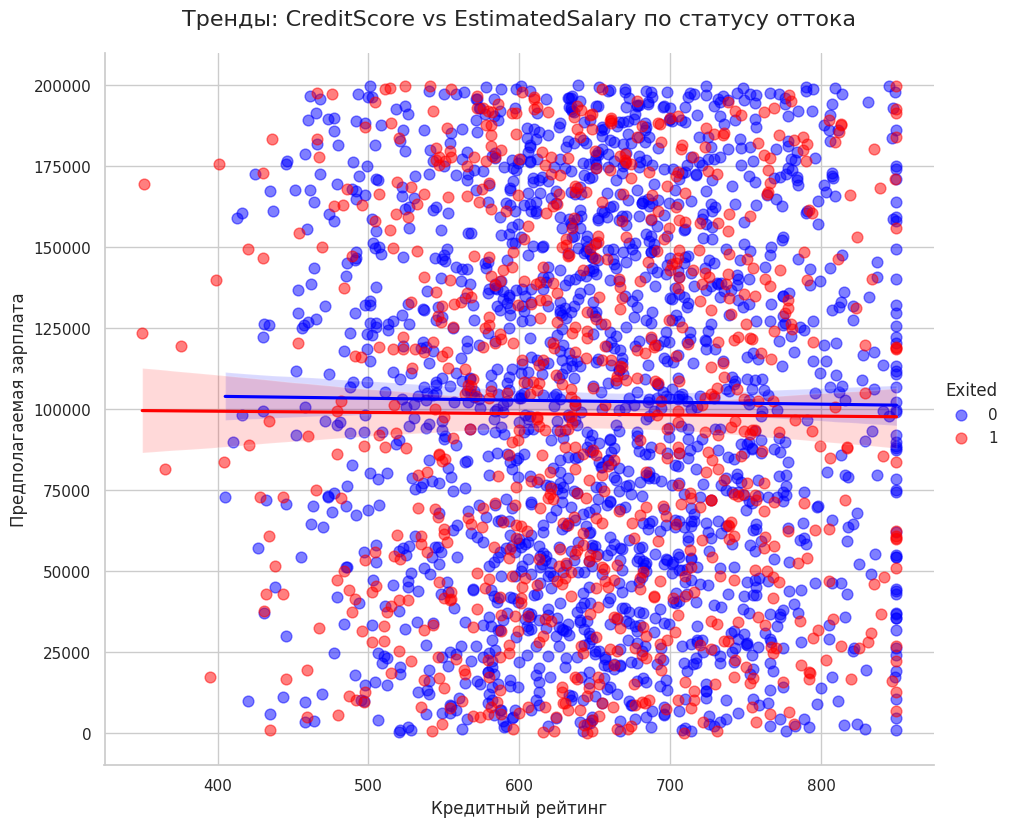

In [7]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
sns.lmplot(
    data=df,
    x='CreditScore',
    y='EstimatedSalary',
    hue='Exited',
    palette={0: 'blue', 1: 'red'},
    height=8,
    aspect=1.2,
    scatter_kws={'alpha': 0.5, 's': 60}
)
plt.title('Тренды: CreditScore vs EstimatedSalary по статусу оттока', fontsize=16, pad=20)
plt.xlabel('Кредитный рейтинг', fontsize=12)
plt.ylabel('Предполагаемая зарплата', fontsize=12)
plt.show()
#КОНЕЦ ВАШЕГО РЕШЕНИЯ


Выводы:
1. Синяя и красная линии почти параллельны и близки — зависимость Salary от CreditScore одинакова для обеих групп. Отток, вероятно, не связан с этой парой признаков.
2. Синяя линяя выше красной, значит в этой группе в среднем выше зарплата при том же кредитном рейтинге. В среднем банк покадают клиенты с чуть большей зарплатой, чем средняя у тех, кто остался.
3. Большой разброс точек вокруг линий, значит связь слабая или нелинейная.

## Задание 6 (13 баллов)
Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

*Подсказка: процент ушедших клиентов в каждой группе можно рассчитать как среднее по столбцу Exited (так как 1 — это ушедшие клиенты, а 0 — лояльные, среднее арифметическое по столбцу обозначает долю ушедших клиентов).*

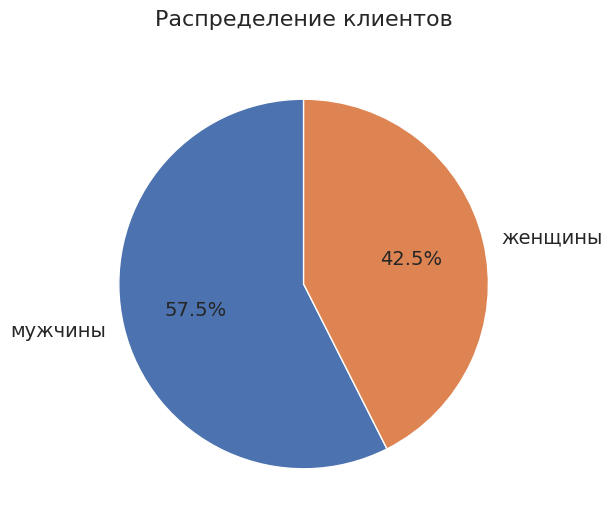

In [8]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ
Exited_count = df.groupby('Gender').agg({'Exited': 'mean'})

Exited_count
plt.figure(figsize=(6, 6))
plt.pie(
    Exited_count['Exited'].values,
    labels=['мужчины', 'женщины'],
    #colors=['#ff9899', '#66b5ff'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 14}
)
plt.title('Распределение клиентов', fontsize=16, pad=20)
plt.show()
#КОНЕЦ ВАШЕГО РЕШЕНИЯ

Вывод: чаще уходят мужчины, доля ушедших мужчин - 57.5%

## Задание 7 (13 баллов)
Как отток клиентов зависит от числа приобретенных у банка услуг? Для ответа на этот вопрос используйте столбчатую диаграмму.

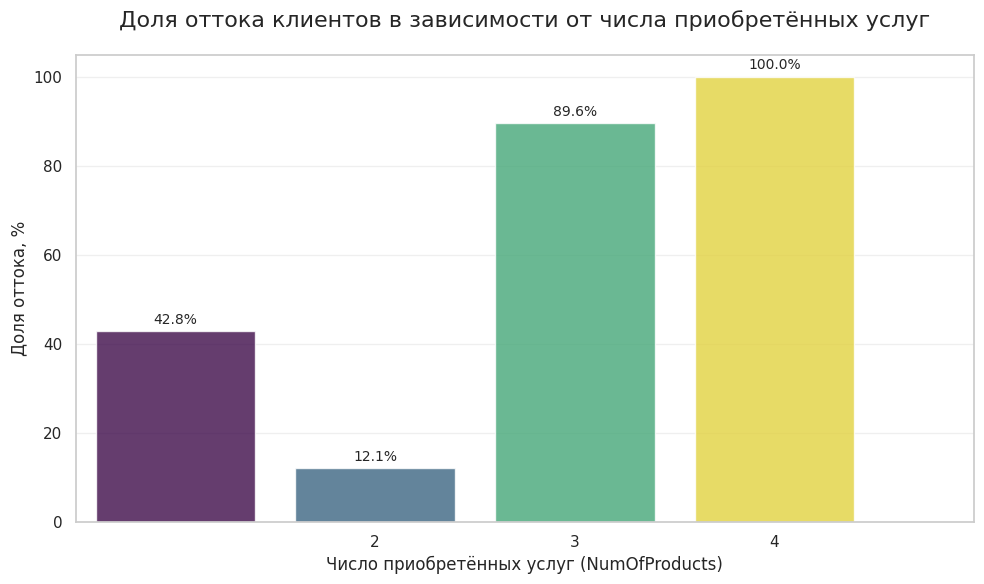

In [9]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ

# Настройка стиля
sns.set_style("whitegrid")

# Группируем данные: для каждого числа услуг считаем долю оттока
churn_by_products = df.groupby('NumOfProducts')['Exited'].mean().reset_index()

# Переводим долю в проценты
churn_by_products['Churn_Rate_%'] = churn_by_products['Exited'] * 100

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(
    data=churn_by_products,
    x='NumOfProducts',
    y='Churn_Rate_%',
    #palette = colors,
    hue='NumOfProducts',
    legend=False,
    palette='viridis',
    alpha=0.8
)

# Оформление
plt.title('Доля оттока клиентов в зависимости от числа приобретённых услуг', fontsize=16, pad=20)
plt.xlabel('Число приобретённых услуг (NumOfProducts)', fontsize=12)
plt.ylabel('Доля оттока, %', fontsize=12)
plt.xticks(churn_by_products['NumOfProducts'])  # Метки по оси X — точные значения NumOfProducts
plt.grid(axis='y', alpha=0.3)


# Добавляем значения процентов над столбцами
for i, val in enumerate(churn_by_products['Churn_Rate_%']):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=10)


plt.tight_layout()
plt.show()

#КОНЕЦ ВАШЕГО РЕШЕНИЯ

In [10]:
print(df['NumOfProducts'].value_counts().sort_index())


NumOfProducts
1    1349
2    1040
3      96
4      24
Name: count, dtype: int64


Вывод: с 3 и 4 приобретённых услуг доля оттока увеличивается, так как таких клиентов мало. Всего 24 клиента, у которых 4 продукта и все они ушли. Это может указывать на то, что клиенты, купившие много продуктов, испытывают сложности с их использованием или считают стоимость неоправданной, при этом с 2 продуктами клиенты наиболее лояльны. Банку стоит проанализировать, какие именно услуги чаще сочетаются с оттоком, и улучшить их поддержку.

## Задание 8 (13 баллов)

Постройте сводную таблицу, где по строкам будет пол (`Gender`), по столбцам — число приобретенных услуг (`NumOfProducts`), а в ячейках — суммарное число ушедших клиентов в этой группе (`Exited`). Затем визуализируйте эту таблицу с помощью тепловой карты и сделайте выводы.

Сводная таблица: число ушедших клиентов по полу и числу услуг
NumOfProducts    1   2   3   4
Gender                        
Female         313  75  46  14
Male           265  51  40  10


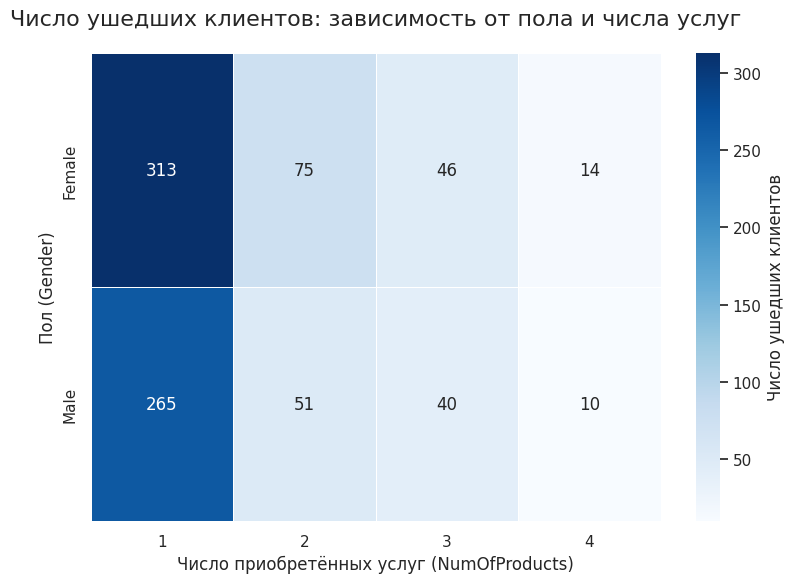

In [11]:
#НАЧАЛО ВАШЕГО РЕШЕНИЯ

pivot_table = pd.pivot_table(
    df,
    index='Gender',           # строки: пол
    columns='NumOfProducts',   # столбцы: число услуг
    values='Exited',         # значение в ячейках
    aggfunc='sum',           # суммируем Exited (число ушедших)
    fill_value=0             # заменяем NaN на 0, если группы нет
)

print("Сводная таблица: число ушедших клиентов по полу и числу услуг")
print(pivot_table)

plt.figure(figsize=(8, 6))

sns.heatmap(
    pivot_table,
    annot=True,           # показываем числа в ячейках
    fmt='d',             # формат: целое число (d = integer)
    cmap='Blues',         # цветовая схема: от светлого к красному
    linewidths=0.5,     # толщина линий между ячейками
    linecolor='white',    # цвет линий
    cbar_kws={'label': 'Число ушедших клиентов'}
)

plt.title('Число ушедших клиентов: зависимость от пола и числа услуг', fontsize=16, pad=20)
plt.xlabel('Число приобретённых услуг (NumOfProducts)', fontsize=12)
plt.ylabel('Пол (Gender)', fontsize=12)


plt.tight_layout()
plt.show()


#КОНЕЦ ВАШЕГО РЕШЕНИЯ

Вывод:
1. Женщины чаще уходят при том же числе услуг.
2. Значение оттока падает слева направо, значит отток снижается (возможно, лояльность растёт) для двух групп.
3. Максимальный отток мужчины и женщины с 1 услугой.
4. Минимальный отток с 4 продуктами в 2 категориях. Либо большая лояльность, либо мало клиентов с 4 продуктами по сравнению с другим количеством продуктов.
